<b>Group Number:</b> 8
<br><b>Name Group Member 1: Anton Seifert</b> 
<br><b>u-Kürzel Group Member 1: unjud</b> 
<br><b>Name Group Member 2: Arne Segatz</b> 
<br><b>u-Kürzel Group Member 2: urnye</b> 


# Convolutional Neural Networks (CNNs) - Part 2
In the following, CNNs will be examined by some common tasks in the field of image processing. Be aware that CNNs can be used in various tasks where many datapoints relate locally to each other.

## 2.1 Some Imports and Preparation
The following initalizations might take some time ...

In [40]:
from ipywidgets import widgets
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np

# For some convolving operations
from scipy import signal
#meine Grafikkarte ist zu alt hilfe
import os
# -1 versteckt die GPU vor TensorFlow -> Es wird die CPU genutzt
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# DeepLearning Library Keras
# Documentation https://keras.io/
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, Reshape
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os, sys
from typing import *

from lama.test_functions import CNN_Tests

test_func = CNN_Tests()

# allow memory to grow, not consume all at once
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Size for some plots with matplotlib
figure_inches = 3

#load tensorboard
import datetime
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


## 2.3 Cifar-10 classification task
Beside the MNIST dataset Cifar10 is as well a small dataset used in the beginning of CNNs. There are 10 different classes of simple objects or animals. The images are of size 32x32x3. In this section, you should tune a given CNN in order to classify images with high accuracy. 

See also: [Cifar-10](https://www.cs.toronto.edu/~kriz/cifar.html)


<div class="alert alert-block alert-success">
<b>Task:</b> Load the dataset, define number of classes, transform labels and define all corresponding classes (like airplane,...) according to the comments in the code cells.

</div>

In [41]:
# Load the dataset from Keras, Tip: cifar10 is already imported, train + test set required
x_train: np.ndarray
y_train: np.ndarray
x_test: np.ndarray
y_test: np.ndarray

# STUDENT CODE HERE (1 pts)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# STUDENT CODE until HERE

In [42]:
# How many classes are in Cifar-10? 
num_classes: int

### STUDENT CODE HERE (1 pts)
print(np.unique(y_train))
num_classes = len(np.unique(y_train))

### STUDENT CODE until HERE

print(num_classes)

[0 1 2 3 4 5 6 7 8 9]
10


In [43]:
# Transform the labels into categorical vectors
# Use the keras.utils.to_categorical function
y_train_categorical: np.ndarray
y_test_categorical: np.ndarray

### STUDENT CODE HERE (1 pts)

y_train_categorical = keras.utils.to_categorical(y_train)
y_test_categorical = keras.utils.to_categorical(y_test)
print(y_train_categorical[:5])
### STUDENT CODE until HERE

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [86]:
# What classes are there? Define them in a list of strings named classes.
classes: List[str]

### STUDENT CODE HERE (2 pts)

classes = [
    "airplane", 
    "automobile", 
    "bird", 
    "cat", 
    "deer", 
    "dog", 
    "frog", 
    "horse", 
    "ship", 
    "truck"
]

### STUDENT CODE until HERE

# Sanity check - compare your results
test_func.test_classes(classes)

Your data looks alright, you can continue with the workbook.


<div class="alert alert-block alert-success">
<b>Task:</b> Check if you defined everything as required.

</div>

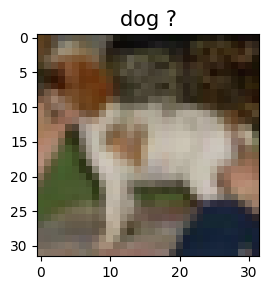

In [45]:
# Image in the training set
number_sample = 12  # test multiple ones

fig, ax = plt.subplots(figsize=(figure_inches, figure_inches))
ax.set_title(classes[y_test[number_sample].item()]+' ?', fontsize = 15)
ax.imshow(x_test[number_sample,:,:,:], interpolation='nearest')
plt.tight_layout()


<div class="alert alert-block alert-success">
<b>Task:</b> Find a picture of a horse (not by try and error) and plot it using the code above. Use the code cell below.

</div>

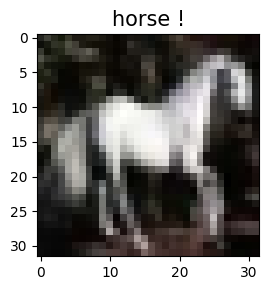

In [46]:
### STUDENT CODE HERE (1 pts)
horse = 7
number_sample = np.where(y_test == horse)[0][0]

fig, ax = plt.subplots(figsize=(figure_inches, figure_inches))
ax.set_title(classes[y_test[number_sample].item()]+' !', fontsize = 15)
ax.imshow(x_test[number_sample,:,:,:], interpolation='nearest')
plt.tight_layout()

### STUDENT CODE until HERE


<div class="alert alert-block alert-success">
<b>Task:</b> Preprocess the data to ensure values between 0 and 1 by dividing rgb values by their maximum value.

</div>

In [47]:
# Data Preprocessing

### STUDENT CODE HERE (1 pts)
print(f"train shape:{x_train.shape}")#50000 bilder mit 32x32 und zu jedem Pixel 3 Farbwerte
print(f"test shape:{x_test.shape}")#10000 bilder mit 32x32 und zu jedem Pixel 3 Farbwerte
x_train = x_train/255 #255 is overall max, dont devide by picture max(würde Rauschen verstärken)
x_test = x_test/255

### STUDENT CODE until HERE

train shape:(50000, 32, 32, 3)
test shape:(10000, 32, 32, 3)


<div class="alert alert-block alert-success">
<b>Question (1 pts):</b> How many training and test samples are there? 
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> 50_000 training samples and 10_000 test samples
</div>

<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> Why normalize the data?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> ML algorithms are made for a scale from 0-1, with higher imputs they wouldn't be stable
</div>

<div class="alert alert-block alert-success">
<b>Question (2 pts):</b>  Question (2 pts): Why using a categorical vector instead of a single output? 
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> the output is is made up of neurons, one neuron wouldn't be sufficient/suitable for a classification task of 10 categories, instead we use softmax. There is no Order in the Outputclasses, which we would suggest by using a single output.
</div>

## 2.4 Classification models for CIFAR-10

### 2.4.1 Neural Network Classifier:

In [48]:
def model_nn() -> tf.keras.Model:
    return Sequential([
        Input(shape = x_train.shape[1:], name='Input_MLP'),
        Flatten(name='Flattening_MLP'),
        Dense(256, activation = 'relu', name='Hidden1_NN'),
        Dense(256, activation = 'relu', name='Hidden2_NN'),
        Dense(num_classes, activation = 'softmax', name='Output_NN')
    ])

### 2.4.2 Convolutional Neural Network Classifier:

In [49]:
def model_cnn() -> tf.keras.Model:
    return Sequential([
        Input(shape = x_train.shape[1:], name='Input_MLP'),
        Conv2D(filters= 16, kernel_size = (3,3), padding='same', activation = 'relu', name='Conv1'),
        MaxPooling2D(pool_size = (2,2), strides = (2,2), padding='valid', name='Pool1'),
        Conv2D(filters = 32, kernel_size = (3,3), padding='same', activation = 'relu', name='Conv2'),
        MaxPooling2D(pool_size = (2,2), strides = (2,2), padding='valid', name='Pool2'),
        Flatten(name='Flatt_CNN'),
        Dense(256, activation = 'relu', name='FC-1'),
        Dense(num_classes, activation = 'softmax', name='Output_CNN')
    ])

### 2.4.3 Comparison of MLP and CNN Classifiers:


<div class="alert alert-block alert-success">
<b>Task:</b> In order to classify the images in Cifar-10, use the given MLP and CNN models to examine which one performs better.
Train both networks for 10 epochs and look at the results.
Feel free to use and change the code in the two code cells down below. If your network does not train, you might have not prepared the rgb-values in the right way (For example: You did not normalize or you did it too often).
</div>

<div class="alert alert-block alert-info">
<b>Note:</b> Structure of code cells below
<ul>
<li> Use the predefined functions to create your model
<li> Define the common TensorBoard logger with the configuration to look at training results later on
<li> Compile and fit the model
<li> Hint: If your models do not learn anything, check your data normalization. You might have not normalized your data or too often.
</li>


</ul>


</div>

In [50]:
# Method for plotting the accuracy history from the model training history
def plot_metric_history(history: tf.keras.callbacks.History, metric: str):
    n_epochs = len(history[metric])

    plt.plot(range(1, n_epochs + 1), history[metric], label=f'train {metric}')
    plt.plot(range(1, n_epochs + 1), history[f'val_{metric}'], label=f'validation {metric}')
    plt.legend()
    plt.title(f'Training and validation {metric} for {n_epochs} epochs of training.')
    plt.show()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flattening_MLP (Flatten)        │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden1_NN (Dense)              │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2_NN (Dense)              │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_NN (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855,050 (3.26 MB)

 Trainable params: 855,050 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.3314 - loss: 1.8545 - val_accuracy: 0.3753 - val_loss: 1.7238
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3986 - loss: 1.6740 - val_accuracy: 0.4303 - val_loss: 1.5920
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4299 - loss: 1.5920 - val_accuracy: 0.4492 - val_loss: 1.5558
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4498 - loss: 1.5432 - val_accuracy: 0.4594 - val_loss: 1.5213
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.4613 - loss: 1.5064 - val_accuracy: 0.4615 - val_loss: 1.4970
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4733 - loss: 1.4779 - val_accuracy: 0.4744 - val_loss: 1.4771
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4833 - loss: 1.4494 - val_accuracy: 0.4420 - val_loss: 1.5542
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4861 - loss: 1.4336 - 

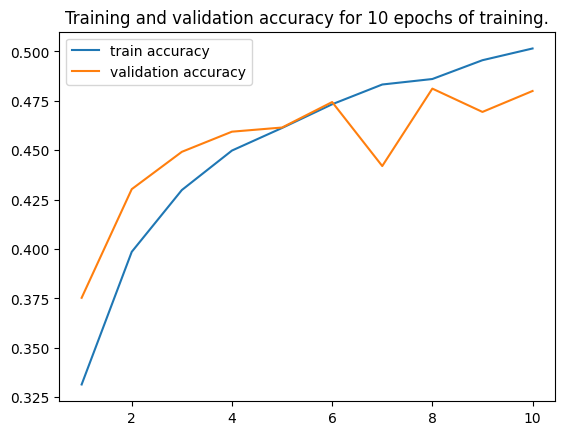

In [ ]:
# Train the Neural Network (MLP)

%reload_ext tensorboard
#!rm -rf ./logs/    #clears the logs
%tensorboard --logdir logs/nn_logs/ #bei localhost:6006 funktionierts, im Notbook ists schrott
                                    #hellere Linien sind die gesmoothden werte
nn_model = model_nn()
nn_model.summary()

model_name = "nn"
time_stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
config_nn = f"{model_name}_{time_stamp}" # give a recognizable name
log_dir = 'logs/nn_logs/'+config_nn

nn_logger = TensorBoard(log_dir = log_dir) 
# The TensorBoard is a feature of tensorflow for the visualization of the training process 


nn_model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='Adam')
history = nn_model.fit(x_train, y_train_categorical, batch_size=64, epochs=10, 
                       validation_data=(x_test, y_test_categorical), 
                       callbacks=[nn_logger], verbose=1)

plot_metric_history(history.history, 'accuracy')

<div class="alert alert-block alert-success">
<b>Task:</b> Use TensorBoard to control your training progress. An explanation on how to open your TensorBoard is given here:
    <a href="https://github.com/tensorflow/tensorboard/blob/master/docs/r1/summaries.md">TensorBoard</a>  (at the bottom of the webpage)
</div>

Reusing TensorBoard on port 6006 (pid 25221), started 0:02:13 ago. (Use '!kill 25221' to kill it.)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatt_CNN (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC-1 (Dense)                    │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_CNN (Dense)              │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,202 (2.03 MB)

 Trainable params: 532,202 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - accuracy: 0.4652 - loss: 1.4949 - val_accuracy: 0.5534 - val_loss: 1.2489
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5955 - loss: 1.1484 - val_accuracy: 0.6220 - val_loss: 1.0833
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6481 - loss: 1.0027 - val_accuracy: 0.6386 - val_loss: 1.0318
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.6830 - loss: 0.9104 - val_accuracy: 0.6517 - val_loss: 1.0114
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7089 - loss: 0.8363 - val_accuracy: 0.6710 - val_loss: 0.9535
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.7330 - loss: 0.7648 - val_accuracy: 0.6832 - val_loss: 0.9210
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7539 - loss: 0.7024 - val_accuracy: 0.6819 - val_loss: 0.9265
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.7754 - loss: 0.6401 - 

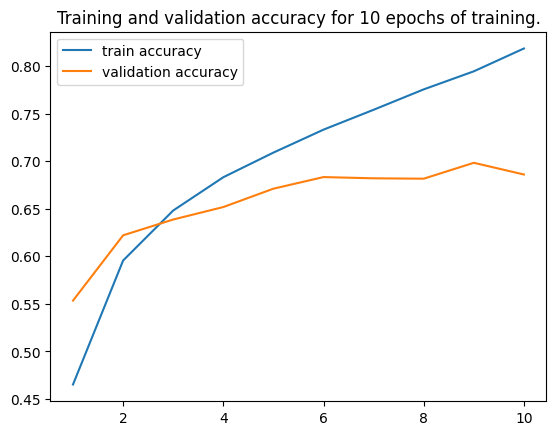

In [52]:
# Train the CNN
import datetime
%reload_ext tensorboard
#!rm -rf ./logs/    #clears the logs
%tensorboard --logdir logs/cnn_logs/ #bei localhost:6006 funktionierts, im Notbook ists schrott
                                    #hellere Linien sind die gesmoothden werte
cnn_model = model_cnn()
cnn_model.summary()

model_name = "cnn"
time_stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
config_cnn = f"{model_name}_{time_stamp}" # give a recognizable name
log_dir = 'logs/cnn_logs/'+config_cnn

cnn_logger = TensorBoard(log_dir = log_dir) 

cnn_model.compile(loss='categorical_crossentropy', metrics = ['accuracy'], optimizer='Adam')
history = cnn_model.fit(x_train, y_train_categorical, batch_size=64, epochs=10, 
                        validation_data=(x_test, y_test_categorical), 
                        callbacks=[cnn_logger], verbose=1)



plot_metric_history(history.history, 'accuracy')

<div class="alert alert-block alert-success">
<b>Question (1 pts):</b> Which network performs better?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> the cnn performed better, but seems like littel bit of overfitting, as the train results got better linearly but the test results even got worse in the end
</div>

<div class="alert alert-block alert-success">
<b>Question (1 pts):</b> How many parameters do the networks have? Therefore use the summary method (see Keras-Docs)...
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> nn: 855,050, cnn:532,202, most of the paramters are located in the neurons of the dense layer
</div>

<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> Where are most parameters stored in this CNN?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> in the dense layer, that converts the compressed information after the filters and pooling into an interpretation
</div>

### 2.4.4 Challenge: Optimize the Network! 

<div class="alert alert-block alert-success">
<b>Task:</b> Try to improve one of the models so that your validation accuracy is higher than 0.75 percent once!

<ul>
<li>Hint: Try to overfit first and then regularize.
<li>Hint2: Therefore use L1/L2 - regularization and/or Dropout. BatchNormalization might improve things as well. Look therefore at Keras website for examples or ask tutors.
<li>Hint3: Use one of the functions <code>def model_nn()</code> or <code>def model_cnn()</code> from above.
<li> Hint4: You are also allowed to increase the number of epochs. Have fun and good Luck!

</li>
</ul>
</div>

Reusing TensorBoard on port 6006 (pid 32821), started 2:05:16 ago. (Use '!kill 32821' to kill it.)

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 32, 32, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 16, 16, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatt_CNN (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC-1 (Dense)                    │ (None, 256)            │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_CNN (Dense)              │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,114 (2.03 MB)

 Trainable params: 532,506 (2.03 MB)

 Non-trainable params: 608 (2.38 KB)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - accuracy: 0.5065 - loss: 1.4262 - val_accuracy: 0.5942 - val_loss: 1.1870
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.6138 - loss: 1.1380 - val_accuracy: 0.4532 - val_loss: 1.6773
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.6547 - loss: 1.0325 - val_accuracy: 0.6727 - val_loss: 0.9965
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.6826 - loss: 0.9631 - val_accuracy: 0.6959 - val_loss: 0.9361
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.7064 - loss: 0.9114 - val_accuracy: 0.6827 - val_loss: 0.9929
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.7228 - loss: 0.8718 - val_accuracy: 0.7158 - val_loss: 0.9002
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 64ms/step - accuracy: 0.7369 - loss: 0.8423 - val_accuracy: 0.6923 - val_loss: 0.9788
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.7501 - loss: 0.8158 - 

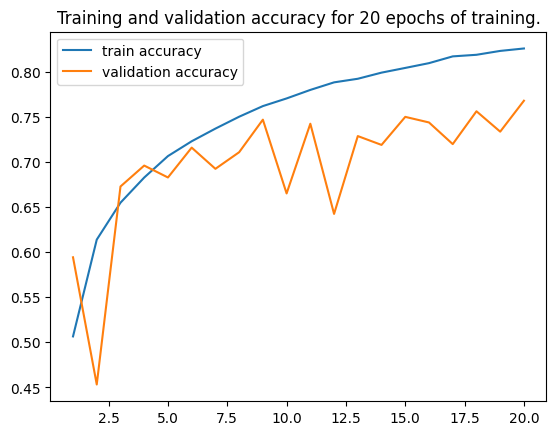

In [ ]:
# Use this block to train the optimized Network.
# You can copy and paste code from above
# You might also want to look online for good training strategies

### STUDENT CODE HERE (8 pts)
def model_cnn_opt() -> tf.keras.Model:
    from tensorflow.keras import regularizers
    from tensorflow.keras.layers import Activation, BatchNormalization

    return Sequential([
        Input(shape = x_train.shape[1:], name='Input_MLP'), #hier ändern macht wenig sinn

        Conv2D(filters= 16, kernel_size = (3,3), padding='same', use_bias = False, name='Conv1', kernel_regularizer= None), #first overfitting
        BatchNormalization(),
        Activation("relu"),

        MaxPooling2D(pool_size = (2,2), strides = (2,2), padding='valid', name='Pool1'), #hier ändern macht wenig sinn
        

        Conv2D(filters = 32, kernel_size = (3,3), padding='same', use_bias = False, name='Conv2', kernel_regularizer= None),
        BatchNormalization(),
        Activation("relu"),

        MaxPooling2D(pool_size = (2,2), strides = (2,2), padding='valid', name='Pool2'), #hier ändern macht wenig sinn
        Flatten(name='Flatt_CNN'), #hier ändern macht wenig sinn

        Dropout(0.45),#0.35

        Dense(256, use_bias = False, name='FC-1', kernel_regularizer= regularizers.l2(0.0001)),#0.000001
        BatchNormalization(),
        Activation("relu"),

        Dense(num_classes, activation = 'softmax', name='Output_CNN') #hier ändern macht wenig sinn
    ])

#running the mdodel
# Train the CNN
import datetime
%reload_ext tensorboard
#!rm -rf ./logs/    #clears the logs
%tensorboard --logdir logs/cnn_opt_logs/ #bei localhost:6006 funktionierts, im Notbook ists schrott
                                    #hellere Linien sind die gesmoothden werte, auch mal localhost:6007 oder so gucken
cnn_model = model_cnn_opt()
cnn_model.summary()

model_name = "cnn_opt"
time_stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
config_cnn = f"{model_name}_{time_stamp}" # give a recognizable name
log_dir = 'logs/cnn_opt_logs/'+config_cnn

cnn_logger = TensorBoard(log_dir = log_dir) 

cnn_model.compile(loss='categorical_crossentropy', metrics = ['accuracy'], optimizer='Adam')
history = cnn_model.fit(x_train, y_train_categorical, batch_size=64, epochs=20, 
                        validation_data=(x_test, y_test_categorical), 
                        callbacks=[cnn_logger], verbose=1)



plot_metric_history(history.history, 'accuracy')

### STUDENT CODE until HERE


<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> Describe briefly what you did to improve your network? Name two things.
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> added Dropout and a bit of L2 regulazation to counteract the overfitting, but in the end it still did a lot of overfitting
</div>

## 2.5 Data Augmentation

Another way to regularize your network is to augment the training data. Use therefore the ImageDataGenerator from Keras. We will later shift and rotate images by ourselves after optimizing on Cifar-10.

In [63]:
# Keras ImageDataGenerator
datagen = ImageDataGenerator(
    featurewise_center=False,
    featurewise_std_normalization=False,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

### 2.5.1 Even more challenging ((Bonus Question :)))

<div class="alert alert-block alert-success">
<b>Task:</b> Improve your model and adapt it, how accurate can it get now?
Our solution is able to reach 0.8894 on the validation accuracy.
</div>

In [108]:
def model_cnn_aug() -> tf.keras.Model:
    from tensorflow.keras import regularizers
    from tensorflow.keras.layers import Activation, BatchNormalization, GlobalAveragePooling2D
    
    return Sequential([
        Input(shape = x_train.shape[1:], name='Input_MLP'), #hier ändern macht wenig sinn

        Conv2D(filters= 32, kernel_size = (3,3), padding='same', use_bias = False, name='Conv1', kernel_regularizer= None), #first overfitting
        BatchNormalization(),
        Activation("relu"),

        MaxPooling2D(pool_size = (2,2), strides = (2,2), padding='valid', name='Pool1'), #hier ändern macht wenig sinn
        

        Conv2D(filters = 64, kernel_size = (3,3), padding='same', use_bias = False, name='Conv2', kernel_regularizer= None),
        BatchNormalization(),
        Activation("relu"),

        MaxPooling2D(pool_size = (2,2), strides = (2,2), padding='valid', name='Pool2'), #hier ändern macht wenig sinn
        
        #third convolution
        Conv2D(filters=128, kernel_size=(3,3), padding='same', use_bias=False, name='Conv3'),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D(pool_size=(2,2), name='Pool3'),
        
        Flatten(name = "Flatten_CNN"),
        #GlobalAveragePooling2D(name='GAP_Layer'), #hier ändern macht wenig sinn
        #bisher beste setting mit 16,32,64 und bisl l2 in dense, kein dropout
        #Dropout(0.4),#0.35

        Dense(256, use_bias = False, name='FC-1', kernel_regularizer= regularizers.l2(0.00001)),#keras.l2(0.00001)
        BatchNormalization(),
        Activation("relu"),

        Dense(num_classes, activation = 'softmax', name='Output_CNN') #hier ändern macht wenig sinn
    ])

Reusing TensorBoard on port 6006 (pid 67243), started 5:57:56 ago. (Use '!kill 67243' to kill it.)

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 32, 32, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 16, 16, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 8, 8, 64)       │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatt_CNN (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC-1 (Dense)                    │ (None, 256)            │       262,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_CNN (Dense)              │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,658 (1.10 MB)

 Trainable params: 288,922 (1.10 MB)

 Non-trainable params: 736 (2.88 KB)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 192ms/step - accuracy: 0.4551 - loss: 1.5159 - val_accuracy: 0.3693 - val_loss: 1.8721 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 183ms/step - accuracy: 0.5566 - loss: 1.2438 - val_accuracy: 0.6028 - val_loss: 1.1415 - learning_rate: 0.0010
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 208ms/step - accuracy: 0.5959 - loss: 1.1350 - val_accuracy: 0.6073 - val_loss: 1.1309 - learning_rate: 0.0010
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 67s 170ms/step - accuracy: 0.6265 - loss: 1.0552 - val_accuracy: 0.6027 - val_loss: 1.2325 - learning_rate: 0.0010
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 211ms/step - accuracy: 0.6473 - loss: 0.9989 - val_accuracy: 0.5402 - val_loss: 1.4326 - learning_rate: 0.0010
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 186ms/step - accuracy: 0.6641 - loss: 0.9565 - val_accuracy: 0.6547 - val_loss: 1.0204 - learning_rate: 0.0010
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 160ms/step - accura

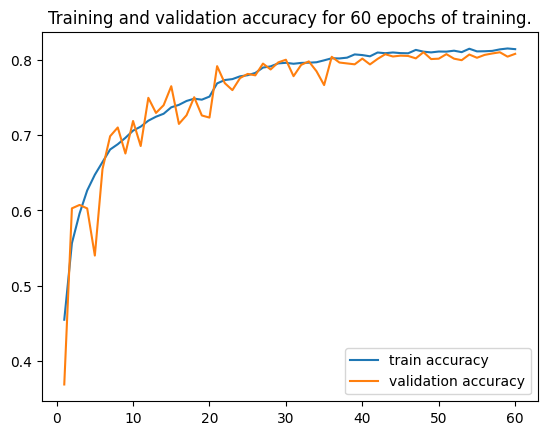

In [ ]:
# Train your model that makes use of data augmentation
# Fit the training data to the data-generator
datagen.fit(x_train)
from tensorflow.keras.callbacks import TensorBoard, ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

#running the mdodel
# Train the CNN
import datetime
%reload_ext tensorboard
#!rm -rf ./logs/    #clears the logs
%tensorboard --logdir logs/cnn_aug_logs/ #bei localhost:6006 funktionierts, im Notbook ists schrott
                                    #hellere Linien sind die gesmoothden werte, auch mal localhost:6007 oder so gucken
cnn_aug_model = model_cnn_aug()
cnn_aug_model.summary()

model_name = "cnn_aug"
time_stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
config_cnn = f"{model_name}_{time_stamp}" # give a recognizable name
log_dir = 'logs/cnn_aug_logs/'+config_cnn

cnn_logger = TensorBoard(log_dir = log_dir) 

# 2. LR Scheduler: Wenn Val-Loss stagniert, Lernrate verringern
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,       # Lernrate halbieren (multipliziere mit 0.5)
    patience=5,       # Warte 5 Epochen ohne Besserung bevor reduziert wird
    min_lr=1e-6,      # Untergrenze für die Lernrate
    verbose=1         # Log-Ausgabe wenn Reduzierung passiert

)
"""
# 3. Early Stopping: Abbruch wenn gar nichts mehr geht
# Wichtig: Patience hier muss größer sein als beim Scheduler, damit die LR-Reduktion Zeit hat zu wirken.
es_callback = EarlyStopping(
    monitor='val_loss', 
    patience=12,      
    restore_best_weights=True
)"""
# Definition des Checkpoints
checkpoint_callback = ModelCheckpoint(
    filepath='models/best_model.keras',       # Dateiname (Endung .keras oder .h5)
    monitor='val_accuracy',            # Worauf soll er achten? (Alternativ: 'val_loss')
    save_best_only=True,               # WICHTIG: Nur speichern, wenn es besser ist als vorher
    mode='max',                        # Bei Accuracy wollen wir 'max', bei Loss 'min'
    verbose=1                          # Gibt im Log aus, wenn gespeichert wird
)

# Train your CNN_augmentation model:

cnn_aug_model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='Adam')

history = cnn_aug_model.fit(datagen.flow(x_train, y_train_categorical, batch_size=128),
                            epochs=100, validation_data=(x_test, y_test_categorical),
                            callbacks=[cnn_logger,lr_scheduler, checkpoint_callback], verbose=1)
plot_metric_history(history.history, 'accuracy')

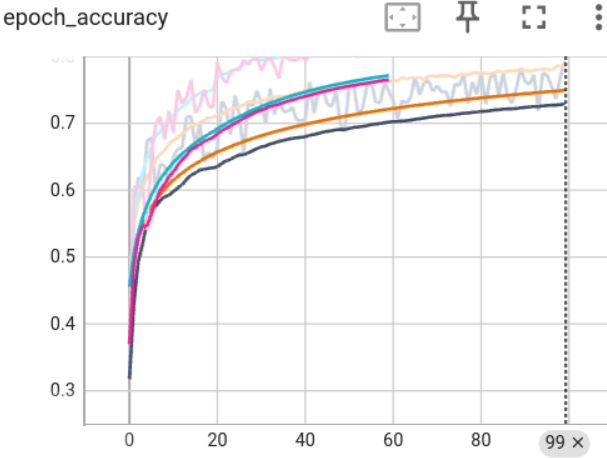

<div class="alert alert-block alert-success">
<b>Question (1 pts):</b> Can you imagine why the ground-truth labels were not augmented in the code cell above and might that be necessary? If the intuition is missing you might come back to this question after you finished the notebook or the implementation of data augmentation down below.  
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> the data augmentationn changes the way the object is displayed for exaple through a rotation, it doesnt change what is displayed, so the labels stay the same
</div>

<div class="alert alert-block alert-success">
<b>Question (1 pts):</b> What do you think happens to images adapted by the DataGenerator?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> they get rotated a bit (+-20degr), vertically and horizontally streched and flipped
</div>

## 2.6 Predict with your model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
airplane : 0.000214
automobile : 0.003477
bird : 0.000371
cat : 0.000129
deer : 0.008735
dog : 0.000161
frog : 0.000077
horse : 0.985107
ship : 0.000005
truck : 0.001724
Predicted Class Index: horse


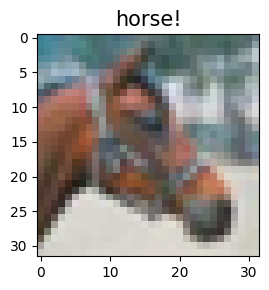

In [106]:
# Get the probabilities of one image prediction
number_sample = 17
x_tester = x_test[number_sample,:,:,:]

# Use numpy expand_dims before predicting with your model
# Print your predicted classes for the first test image (x_test[0,:,:,:])

# STUDENT CODE HERE (2 pts)
x_input = np.expand_dims(x_tester, axis=0)

pred = cnn_aug_model.predict(x_input)
for i, label in enumerate(classes):
    print(f"{label} : {pred[0][i]:.6f}")
print("Predicted Class Index:", classes[np.argmax(pred)])

fig, ax = plt.subplots(figsize=(figure_inches, figure_inches))
ax.set_title(classes[y_test[number_sample].item()]+'!', fontsize = 15)
ax.imshow(x_test[number_sample,:,:,:], interpolation='nearest')
plt.tight_layout()
# STUDENT CODE until HERE


<div class="alert alert-block alert-success">
<b>Question (1 pts):</b> With how much confidence was image <b>18</b> (index 17) in the test set predicted as a bird by your model?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> bird : 0.000371
</div>

## 2.7 Let's have a closer look / Get the weights in a convolutional layer

In [107]:
# Get the weights of a layer of one of your models, you specified by name
layer_visual = cnn_model.get_layer('Conv1')
weights = layer_visual.get_weights()[0]

# Take some of them, last dimension are the channels
weights_2d = weights[:,:,0,0] # filters are [:,:, dimension of spatial input (e.g.: rgb=3), nb_filters] in a layer
weights_2d

array([[ 0.10097097, -0.1990436 ,  0.03633451],
       [ 0.12286894, -0.24413802,  0.09039144],
       [ 0.1184156 , -0.21024753,  0.21264173]], dtype=float32)

<div class="alert alert-block alert-success">
<b>Task:</b> Look at layer Conv2 (or another layer than conv1) and plot one filter-kernel-slice of it's 3rd filter. Hint: Use weights.shape to understand the kernel's dimensions.
</div>

In [110]:
# Copy and paste necessary code for this Task from above.
### STUDENT CODE HERE (1 pts)
# Get the weights of a layer of one of your models, you specified by name
layer_visual = cnn_model.get_layer('Conv2')
weights = layer_visual.get_weights()[0]
print(weights.shape)

# Take some of them, last dimension are the channels
weights_2d = weights[:,:,0,0] # filters are [:,:, dimension of spatial input (e.g.: rgb=3), nb_filters] in a layer
weights_2d

### STUDENT CODE until HERE


(3, 3, 16, 32)


array([[-0.2275938 , -0.14175332, -0.09751517],
       [-0.10060547, -0.07486825, -0.10021161],
       [-0.02319761, -0.00987302, -0.03806992]], dtype=float32)

<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> Explain what the dimensions a,b,c and d are in 'weights[a,b,c,d]' like it is used in the code block above. 
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> a,b are the dimension of the convolution matrix, c is the number of filters used in the layer before(input), d is the number of filters used in the layer(output dimension).

</div>

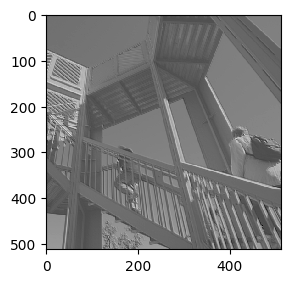

In [60]:
#Load Ascent image from scipy and convolve it with the previous loaded filter
import scipy.datasets
import scipy.signal

ascent = scipy.datasets.ascent()
ascent = scipy.signal.convolve2d(ascent, weights_2d, boundary='symm', mode='same')
# ascent = np.maximum(ascent, 0)
fig, ax = plt.subplots(figsize=(figure_inches, figure_inches))
ax.imshow(ascent, interpolation='nearest', cmap='gray')
plt.tight_layout()

<div class="alert alert-block alert-success">
<b>Task:</b> Use different filters on the input image. Can you notice any differences? (A few words)
</div>

(3, 3, 16, 32)


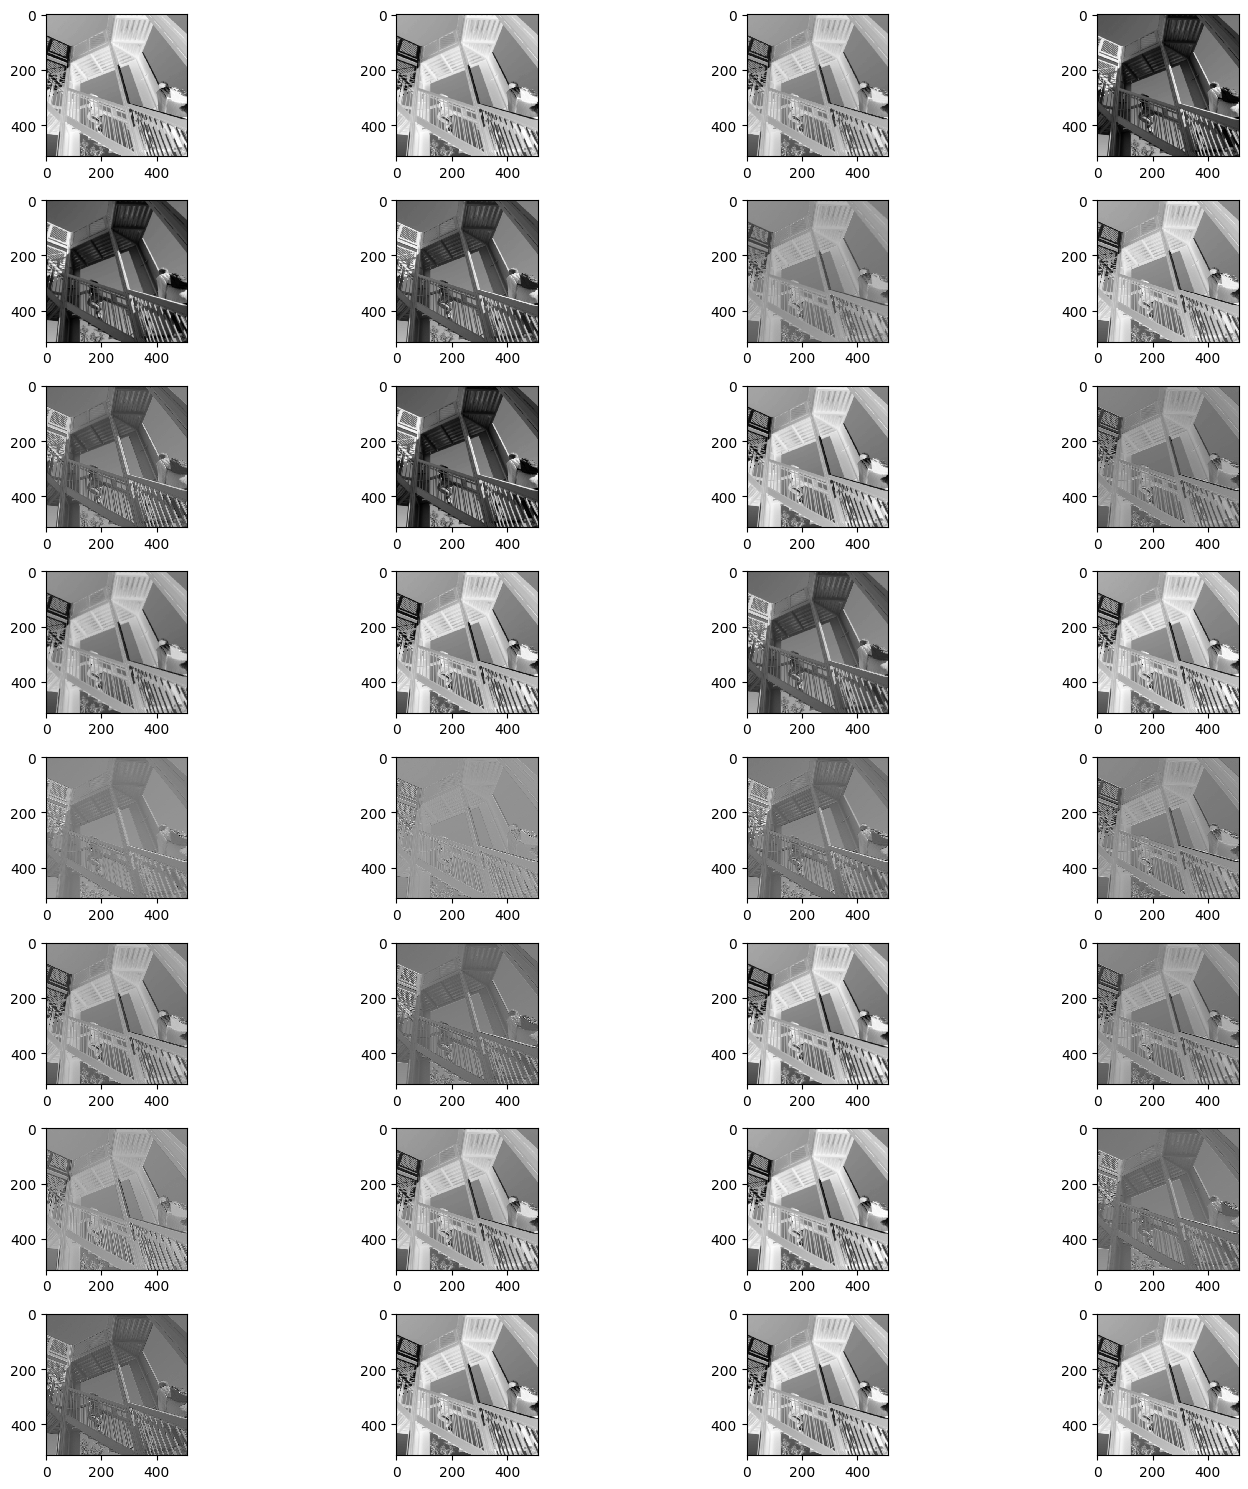

In [121]:
# Copy and paste the code from above. And use different filters.

# STUDENT CODE HERE (3 pts)
layer_visual = cnn_model.get_layer('Conv2')
weights = layer_visual.get_weights()[0]# [1]would be the biases

print(weights.shape)
fig, ax = plt.subplots(nrows= 8, ncols=4, figsize=(15, 15))
ax = ax.flatten()
image = scipy.datasets.ascent()

for i in range(weights.shape[3]):
    weights_2d = weights[:,:,0,i]
    ascent = scipy.signal.convolve2d(image, weights_2d, boundary='symm', mode='same')
    # ascent = np.maximum(ascent, 0)
    
    ax[i].imshow(ascent, interpolation='nearest', cmap='gray')


plt.tight_layout()
plt.show()

# STUDENT CODE until HERE

<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> Explain briefly what you changed in the pasted code.
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> got  all the filters out of the conv2 layer(output) and applied them to the original picture.
</div>

## 2.8 Visualize the activation in a feedforward pass

In the following code we will directly use the output of the convolutional layer in the CNN and visualize it. This is approximately the same as we did above.  

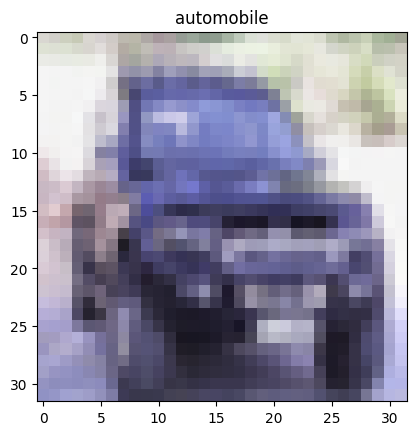

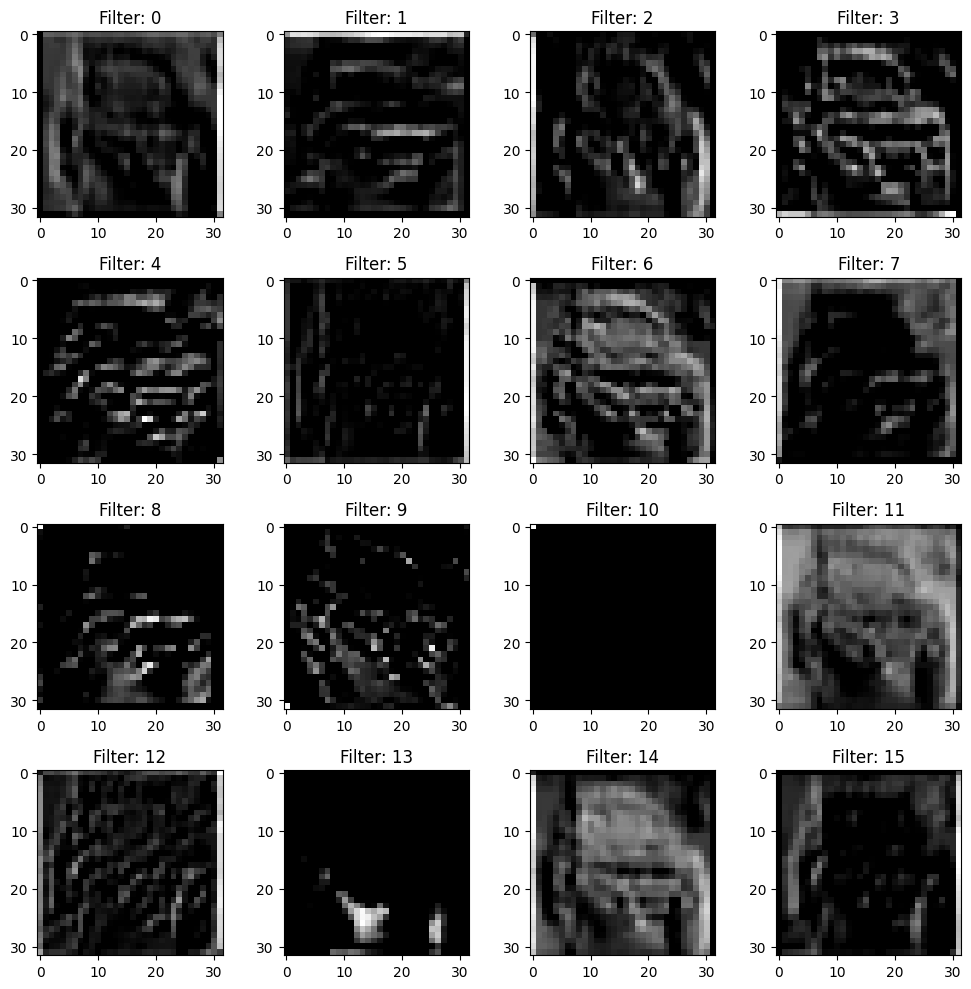

In [62]:
# Get the output in a feedforward process from a model with get_output function
number_sample = 9

def get_output(model, layer_name, model_input):
    """Function to get activations of a given layer after a feedforward pass.
    
    This approach works with Sequential models that may not have been built yet.
    """
    # Create a new functional model by reconstructing layers up to target layer
    input_layer = keras.Input(shape=model_input.shape[1:])
    x = input_layer
    
    # Apply each layer up to and including the target layer
    for layer in model.layers:
        x = layer(x)
        if layer.name == layer_name:
            break
    
    # Create the partial model
    partial_model = keras.Model(inputs=input_layer, outputs=x)
    return partial_model(model_input)

# Model and layer where the feature maps come from
feature_map = get_output(cnn_model, 'Conv1', np.expand_dims(x_test[number_sample,:,:,:],axis=0))

# First print sample
plt.imshow(x_test[number_sample,:,:,:])
plt.title(classes[y_test[number_sample].item()])

# Now plot all filters
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(10,10))
axes = ax.flatten()

# Note: it only works for 16 filters, if you want to doodle nrows * ncols
for i, ax in enumerate(axes):
    ax.imshow(feature_map[0,:,:,i], cmap='gray')
    ax.set_title(f"Filter: {i}")

fig.tight_layout()
plt.show()

## Further Reading

[SegmentationForAutonomousDriving](https://blog.playment.io/semantic-segmentation-models-autonomous-vehicles/#U-Net)

[Dropout](http://www.cs.toronto.edu/~rsalakhu/papers/srivastava14a.pdf)

[BatchNormalization](https://arxiv.org/pdf/1502.03167.pdf)